# PPMI Parkinson's Disease Detection using Machine Learning

## Objective
Build a machine learning pipeline to predict Parkinson’s disease using multiple PPMI clinical datasets.

Unlike the UCI dataset, PPMI is more realistic and more complex because it contains:
- Multiple CSV files
- Patient visit records
- Motor assessment scores
- Diagnosis/history information
- Missing values
- Potentially imbalanced classes

## Challenges

Working with PPMI is more complex than UCI because:
- The data is distributed across multiple files
- There are missing values
- The dataset is highly imbalanced
- The features are heterogeneous (clinical, motor, and visit-based)

## Files Used
1. `Participant-visit_information__Online__24Apr2026.csv`
2. `PD_history__return_study_visit_for_PD_cohort___Online__24Apr2026.csv`
3. `motor_part2.csv`
4. `motor_part3.csv`

## Merge Key
The common columns used to merge files are:

- `PATNO`: patient number
- `EVENT_ID`: visit/event identifier

## Models Used
We use the same models as in the UCI experiment for consistency and comparison.

1. Logistic Regression
2. Gradient Boosting Classifier

## Main Steps
1. Load datasets  
2. Inspect datasets  
3. Select useful columns  
4. Merge datasets  
5. Handle missing values (imputation)  
6. Prepare target variable  
7. Train/test split  
8. Handle class imbalance using SMOTE  
9. Train two models  
10. Evaluate models  
11. Apply adversarial label noise  
12. Compare clean vs noisy-label performance  
13. Write interpretation and limitations  

In [ ]:
# =========================
# 1. Import libraries
# =========================

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix,
    RocCurveDisplay
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Load PPMI Datasets

We load the four PPMI CSV files.

Because PPMI files can be large, we use `low_memory=False` to avoid mixed-type warnings.

In [ ]:
# =========================
# 2. Load datasets
# =========================

visit_path = "Participant-visit_information__Online__24Apr2026.csv"
history_path = "PD_history__return_study_visit_for_PD_cohort___Online__24Apr2026.csv"
motor2_path = "motor_part2.csv"
motor3_path = "motor_part3.csv"

visit_df = pd.read_csv(visit_path, low_memory=False)
history_df = pd.read_csv(history_path, low_memory=False)
motor2_df = pd.read_csv(motor2_path, low_memory=False)
motor3_df = pd.read_csv(motor3_path, low_memory=False)

print("Visit shape:", visit_df.shape)
print("History shape:", history_df.shape)
print("Motor Part 2 shape:", motor2_df.shape)
print("Motor Part 3 shape:", motor3_df.shape)

Visit shape: (716328, 11)
History shape: (79192, 8)
Motor Part 2 shape: (35475, 22)
Motor Part 3 shape: (37639, 65)


## 3. Initial Inspection

We check the first few rows and column names of each dataset.

In [ ]:
# Display first rows
display(visit_df.head())
display(history_df.head())
display(motor2_df.head())
display(motor3_df.head())

,PATNO,EVENT_ID,PATNO_EVENT_ID_OL,ACTIVE_DIAGNOSIS_OL,ENGAGE_END_OL,ENGAGE_START_OL,EVENT_END_OL,EVENT_START_OL,NUM_COMPLETED_OL,NUM_INSTRUMENTS_OL,NUM_STARTED_OL
0,100001,OL01,100001_OL01,NaN,11/2022,11/2021,12/2021,11/2021,19,28,0
1,100001,OL02,100001_OL02,NaN,01/2022,01/2022,03/2022,01/2022,13,19,0
2,100001,OL03,100001_OL03,NaN,05/2022,05/2022,05/2022,04/2022,8,18,0
3,100001,OL04,100001_OL04,NaN,08/2022,08/2022,08/2022,07/2022,12,19,0
4,100001,OL05,100001_OL05,NaN,05/2023,11/2022,11/2022,10/2022,17,26,0


,PATNO,EVENT_ID,MODIFIED_AT,CREATED_AT,RESPONSE_STATUS,SURVEY_VERSION,RETURNPD_DIAG_STATUS_OL,RETURNPD_DIAG_COND_OL
0,470312,OL02,02/2026,02/2026,1,4.0,1,NaN
1,469446,OL03,01/2026,01/2026,1,4.0,1,NaN
2,432941,OL04,11/2025,11/2025,1,3.0,1,NaN
3,469110,OL03,01/2026,01/2026,1,4.0,1,NaN
4,469104,OL02,10/2025,10/2025,1,3.0,1,NaN


,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,NUPSOURC,NP2SPCH,NP2SALV,NP2SWAL,NP2EAT,...,NP2HWRT,NP2HOBB,NP2TURN,NP2TRMR,NP2RISE,NP2WALK,NP2FREZ,NP2PTOT,ORIG_ENTRY,LAST_UPDATE
0,272451701,3000,BL,NUPDRS2P,02/2011,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,02/2011,2020-06-25 16:02:19
1,338702901,3000,V04,NUPDRS2P,03/2012,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,03/2012,2020-06-25 16:02:22
2,385009601,3000,V06,NUPDRS2P,02/2013,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,02/2013,2020-06-25 16:02:22
3,437131001,3000,V08,NUPDRS2P,03/2014,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,05/2014,2020-06-25 16:02:22
4,512467901,3000,V10,NUPDRS2P,03/2015,1,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,03/2015,2020-06-25 16:02:23


,REC_ID,PATNO,EVENT_ID,PAG_NAME,INFODT,PDTRTMNT,PDSTATE,HRPOSTMED,HRDBSON,HRDBSOFF,...,NP3RTARL,NP3RTALL,NP3RTALJ,NP3RTCON,NP3TOT,DYSKPRES,DYSKIRAT,NHY,ORIG_ENTRY,LAST_UPDATE
0,272451901,3000,BL,NUPDRS3,02/2011,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,4.0,0.0,NaN,0.0,02/2011,2020-06-25 16:02:19
1,338703101,3000,V04,NUPDRS3,03/2012,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,1.0,0.0,NaN,0.0,03/2012,2020-06-25 16:02:22
2,385009801,3000,V06,NUPDRS3,02/2013,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,4.0,0.0,NaN,0.0,02/2013,2020-06-25 16:02:22
3,437131401,3000,V08,NUPDRS3,03/2014,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,2.0,0.0,NaN,0.0,05/2014,2020-06-25 16:02:22
4,512469901,3000,V10,NUPDRS3,03/2015,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,19.0,0.0,NaN,0.0,03/2015,2020-06-25 16:02:23


In [ ]:
# Print column names
print("Visit columns:")
print(list(visit_df.columns))

print("\nHistory columns:")
print(list(history_df.columns))

print("\nMotor Part 2 columns:")
print(list(motor2_df.columns))

print("\nMotor Part 3 columns:")
print(list(motor3_df.columns))

Visit columns:
['PATNO', 'EVENT_ID', 'PATNO_EVENT_ID_OL', 'ACTIVE_DIAGNOSIS_OL', 'ENGAGE_END_OL', 'ENGAGE_START_OL', 'EVENT_END_OL', 'EVENT_START_OL', 'NUM_COMPLETED_OL', 'NUM_INSTRUMENTS_OL', 'NUM_STARTED_OL']

History columns:
['PATNO', 'EVENT_ID', 'MODIFIED_AT', 'CREATED_AT', 'RESPONSE_STATUS', 'SURVEY_VERSION', 'RETURNPD_DIAG_STATUS_OL', 'RETURNPD_DIAG_COND_OL']

Motor Part 2 columns:
['REC_ID', 'PATNO', 'EVENT_ID', 'PAG_NAME', 'INFODT', 'NUPSOURC', 'NP2SPCH', 'NP2SALV', 'NP2SWAL', 'NP2EAT', 'NP2DRES', 'NP2HYGN', 'NP2HWRT', 'NP2HOBB', 'NP2TURN', 'NP2TRMR', 'NP2RISE', 'NP2WALK', 'NP2FREZ', 'NP2PTOT', 'ORIG_ENTRY', 'LAST_UPDATE']

Motor Part 3 columns:
['REC_ID', 'PATNO', 'EVENT_ID', 'PAG_NAME', 'INFODT', 'PDTRTMNT', 'PDSTATE', 'HRPOSTMED', 'HRDBSON', 'HRDBSOFF', 'PDMEDYN', 'DBSYN', 'ONOFFORDER', 'OFFEXAM', 'OFFNORSN', 'DBSOFFYN', 'DBSOFFTM', 'ONEXAM', 'ONNORSN', 'HIFUYN', 'DBSONYN', 'DBSONTM', 'PDMEDDT', 'PDMEDTM', 'EXAMDT', 'EXAMTM', 'NP3SPCH', 'NP3FACXP', 'NP3RIGN', 'NP3RIGRU', 'N

## 4. Select Useful Columns

To keep the first PPMI pipeline simple and clean, we select only important columns.

### Target source
The target comes from the history file:

- `RETURNPD_DIAG_STATUS_OL`

### Clinical features
We use:
- Visit completion information
- Motor Part II total score
- Motor Part III total score

This gives us a simple clinical dataset that is easier to understand and model.

In [ ]:
# =========================
# 4. Select useful columns
# =========================

# History columns: contains the target
history_cols = [
    "PATNO",
    "EVENT_ID",
    "RETURNPD_DIAG_STATUS_OL",
    "RETURNPD_DIAG_COND_OL"
]

# Visit columns: simple visit-level features
visit_cols = [
    "PATNO",
    "EVENT_ID",
    "ACTIVE_DIAGNOSIS_OL",
    "NUM_COMPLETED_OL",
    "NUM_INSTRUMENTS_OL",
    "NUM_STARTED_OL"
]

# Motor Part II: daily living motor experiences
motor2_cols = [
    "PATNO",
    "EVENT_ID",
    "NP2PTOT"
]

# Motor Part III: motor examination score
motor3_cols = [
    "PATNO",
    "EVENT_ID",
    "NP3TOT"
]

history_selected = history_df[[col for col in history_cols if col in history_df.columns]].copy()
visit_selected = visit_df[[col for col in visit_cols if col in visit_df.columns]].copy()
motor2_selected = motor2_df[[col for col in motor2_cols if col in motor2_df.columns]].copy()
motor3_selected = motor3_df[[col for col in motor3_cols if col in motor3_df.columns]].copy()

print("Selected history shape:", history_selected.shape)
print("Selected visit shape:", visit_selected.shape)
print("Selected motor2 shape:", motor2_selected.shape)
print("Selected motor3 shape:", motor3_selected.shape)

Selected history shape: (79192, 4)
Selected visit shape: (716328, 6)
Selected motor2 shape: (35475, 3)
Selected motor3 shape: (37639, 3)


## 5. Check Duplicates Before Merging

Since we merge using `PATNO` and `EVENT_ID`, duplicate rows with the same key can create repeated rows after merging.

We check duplicates and aggregate motor scores by mean if needed.

In [ ]:
# =========================
# 5. Duplicate checks
# =========================

merge_keys = ["PATNO", "EVENT_ID"]

def duplicate_count(df, keys, name):
    duplicates = df.duplicated(subset=keys).sum()
    print(f"{name} duplicate rows based on {keys}: {duplicates}")

duplicate_count(history_selected, merge_keys, "History")
duplicate_count(visit_selected, merge_keys, "Visit")
duplicate_count(motor2_selected, merge_keys, "Motor Part 2")
duplicate_count(motor3_selected, merge_keys, "Motor Part 3")

History duplicate rows based on ['PATNO', 'EVENT_ID']: 0
Visit duplicate rows based on ['PATNO', 'EVENT_ID']: 0
Motor Part 2 duplicate rows based on ['PATNO', 'EVENT_ID']: 1
Motor Part 3 duplicate rows based on ['PATNO', 'EVENT_ID']: 6518


In [ ]:
# Aggregate duplicate keys if they exist
# For numeric columns, we take the mean per patient visit.

def aggregate_by_visit(df, keys):
    numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
    numeric_cols = [c for c in numeric_cols if c not in keys]

    non_numeric_cols = [c for c in df.columns if c not in keys and c not in numeric_cols]

    agg_dict = {}
    for col in numeric_cols:
        agg_dict[col] = "mean"
    for col in non_numeric_cols:
        agg_dict[col] = "first"

    return df.groupby(keys, as_index=False).agg(agg_dict)

history_selected = aggregate_by_visit(history_selected, merge_keys)
visit_selected = aggregate_by_visit(visit_selected, merge_keys)
motor2_selected = aggregate_by_visit(motor2_selected, merge_keys)
motor3_selected = aggregate_by_visit(motor3_selected, merge_keys)

print("After aggregation:")
print("History:", history_selected.shape)
print("Visit:", visit_selected.shape)
print("Motor Part 2:", motor2_selected.shape)
print("Motor Part 3:", motor3_selected.shape)

After aggregation:
History: (79192, 4)
Visit: (716328, 6)
Motor Part 2: (35474, 3)
Motor Part 3: (31121, 3)


## 6. Merge the PPMI Files

We merge all files into one dataset using:

- `PATNO`
- `EVENT_ID`

We start from the history dataset because it contains the target.

In [ ]:
# =========================
# 6. Merge datasets
# =========================

ppmi_df = (
    history_selected
    .merge(visit_selected, on=merge_keys, how="left")
    .merge(motor2_selected, on=merge_keys, how="left")
    .merge(motor3_selected, on=merge_keys, how="left")
)

print("Merged PPMI shape:", ppmi_df.shape)
display(ppmi_df.head())

Merged PPMI shape: (79192, 10)


,PATNO,EVENT_ID,RETURNPD_DIAG_STATUS_OL,RETURNPD_DIAG_COND_OL,ACTIVE_DIAGNOSIS_OL,NUM_COMPLETED_OL,NUM_INSTRUMENTS_OL,NUM_STARTED_OL,NP2PTOT,NP3TOT
0,3003,OL02,1.0,NaN,NaN,13.0,19.0,0.0,NaN,NaN
1,3003,OL05,1.0,NaN,NaN,17.0,26.0,0.0,NaN,NaN
2,3003,OL06,1.0,NaN,NaN,13.0,19.0,0.0,NaN,NaN
3,3003,OL07,1.0,NaN,NaN,9.0,18.0,0.0,NaN,NaN
4,3003,OL12,1.0,NaN,NaN,18.0,19.0,0.0,NaN,NaN


## 7. Missing Values Analysis

PPMI data is clinical and real-world, so missing values are expected.

We inspect missing values before cleaning.

,0
NP3TOT,100.000000
ACTIVE_DIAGNOSIS_OL,100.000000
NP2PTOT,100.000000
RETURNPD_DIAG_COND_OL,98.819325
EVENT_ID,0.000000
PATNO,0.000000
NUM_COMPLETED_OL,0.000000
RETURNPD_DIAG_STATUS_OL,0.000000
NUM_STARTED_OL,0.000000
NUM_INSTRUMENTS_OL,0.000000


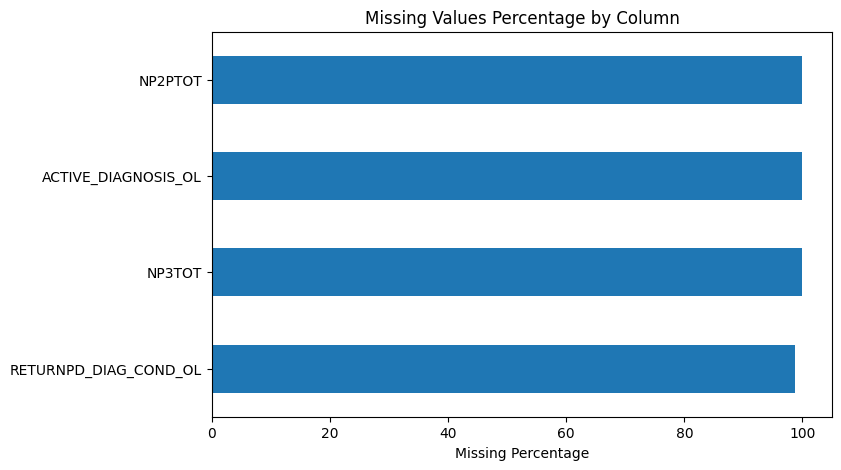

In [ ]:
# =========================
# 7. Missing values
# =========================

missing_percent = (ppmi_df.isnull().mean() * 100).sort_values(ascending=False)
display(missing_percent)

plt.figure(figsize=(8, 5))
missing_percent[missing_percent > 0].sort_values().plot(kind="barh")
plt.title("Missing Values Percentage by Column")
plt.xlabel("Missing Percentage")
plt.show()

In [ ]:
# =========================
# CLEAN PREPROCESSING
# =========================

target_col = "RETURNPD_DIAG_STATUS_OL"

print("Raw target distribution:")
display(ppmi_df[target_col].value_counts(dropna=False).sort_index())

# 1. Drop rows with missing target
ppmi_df = ppmi_df.dropna(subset=[target_col]).copy()

# 2. Prepare target
raw_target = ppmi_df[target_col].astype(int)

majority_class = raw_target.value_counts().idxmax()
y = (raw_target != majority_class).astype(int)

print("Majority class treated as 0:", majority_class)
print("\nBinary target distribution:")
display(y.value_counts().sort_index())

# 3. Prepare features
columns_to_drop = [
    "PATNO",
    "EVENT_ID",
    "RETURNPD_DIAG_STATUS_OL",
    "RETURNPD_DIAG_COND_OL"
]

X = ppmi_df.drop(columns=columns_to_drop, errors="ignore")

# 4. Keep numeric columns only
X = X.select_dtypes(include=[np.number]).copy()

# 5. Fill missing values
X = X.fillna(X.median(numeric_only=True))

# 6. Final safety check
print("Feature columns:")
print(list(X.columns))

print("\nFeature matrix shape:", X.shape)
print("Remaining NaNs:", X.isnull().sum().sum())

print("\nNaNs per column:")
print(X.isnull().sum().sort_values(ascending=False).head())

Raw target distribution:


,count
RETURNPD_DIAG_STATUS_OL,
1.0,77415
2.0,933
3.0,186
4.0,621
5.0,37


Majority class treated as 0: 1

Binary target distribution:


,count
RETURNPD_DIAG_STATUS_OL,
0,77415
1,1777


Feature columns:
['ACTIVE_DIAGNOSIS_OL', 'NUM_COMPLETED_OL', 'NUM_INSTRUMENTS_OL', 'NUM_STARTED_OL', 'NP2PTOT', 'NP3TOT']

Feature matrix shape: (79192, 6)
Remaining NaNs: 237576

NaNs per column:
ACTIVE_DIAGNOSIS_OL    79192
NP3TOT                 79192
NP2PTOT                79192
NUM_COMPLETED_OL           0
NUM_STARTED_OL             0
dtype: int64


## 11. Train/Test Split

We use a stratified split to preserve class distribution in both training and testing sets.

In [ ]:
# =========================
# 11. Train-test split + Fix NaN Columns + SMOTE
# =========================

from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE

# Remove columns that are completely empty
X = X.dropna(axis=1, how="all")

print("Final feature columns used:")
print(list(X.columns))
print("X shape before split:", X.shape)

# Split data first
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("\nBefore SMOTE:")
print(y_train.value_counts().sort_index())

# Impute missing values before SMOTE
imputer = SimpleImputer(strategy="median")

X_train = pd.DataFrame(
    imputer.fit_transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    imputer.transform(X_test),
    columns=X_test.columns
)

print("\nNaNs in X_train after imputation:", X_train.isnull().sum().sum())
print("NaNs in X_test after imputation:", X_test.isnull().sum().sum())

# Apply SMOTE only on training data
smote = SMOTE(random_state=RANDOM_STATE)

X_train, y_train = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(y_train.value_counts().sort_index())

print("\nX_train:", X_train.shape)
print("X_test:", X_test.shape)

print("\nTrain target distribution after SMOTE:")
display(y_train.value_counts(normalize=True).sort_index())

print("\nTest target distribution:")
display(y_test.value_counts(normalize=True).sort_index())

Final feature columns used:
['NUM_COMPLETED_OL', 'NUM_INSTRUMENTS_OL', 'NUM_STARTED_OL']
X shape before split: (79192, 3)

Before SMOTE:
RETURNPD_DIAG_STATUS_OL
0    61931
1     1422
Name: count, dtype: int64

NaNs in X_train after imputation: 0
NaNs in X_test after imputation: 0

After SMOTE:
RETURNPD_DIAG_STATUS_OL
0    61931
1    61931
Name: count, dtype: int64

X_train: (123862, 3)
X_test: (15839, 3)

Train target distribution after SMOTE:


,proportion
RETURNPD_DIAG_STATUS_OL,
0,0.5
1,0.5



Test target distribution:


,proportion
RETURNPD_DIAG_STATUS_OL,
0,0.977587
1,0.022413


## 12. Define the Two Models

We use the same models as the UCI part:

### Logistic Regression
A simple and interpretable baseline model.

### Gradient Boosting
A stronger tree-based model for non-linear relationships.

In [ ]:
from sklearn.impute import SimpleImputer

models = {
    "Logistic Regression": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=2000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        ))
    ]),

    "Gradient Boosting": Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
    ])
}

## 13. Evaluation Function

This function trains and evaluates each model using:

- Accuracy
- Precision
- Recall
- F1-score
- ROC-AUC
- Classification report
- Confusion matrix
- ROC curve

In [ ]:
# =========================
# 13. Evaluation function
# =========================

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name):
    """Train and evaluate a binary classification model."""

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1-score": f1_score(y_test, y_pred, zero_division=0),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }

    print("=" * 60)
    print(model_name)
    print("=" * 60)
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, zero_division=0))

    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    RocCurveDisplay.from_estimator(model, X_test, y_test)
    plt.title(f"ROC Curve - {model_name}")
    plt.show()

    return results

## 14. Train and Evaluate on Clean PPMI Data

Logistic Regression

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.62      0.76     15484
           1       0.02      0.39      0.04       355

    accuracy                           0.62     15839
   macro avg       0.50      0.51      0.40     15839
weighted avg       0.96      0.62      0.74     15839

Confusion Matrix:
[[9630 5854]
 [ 215  140]]


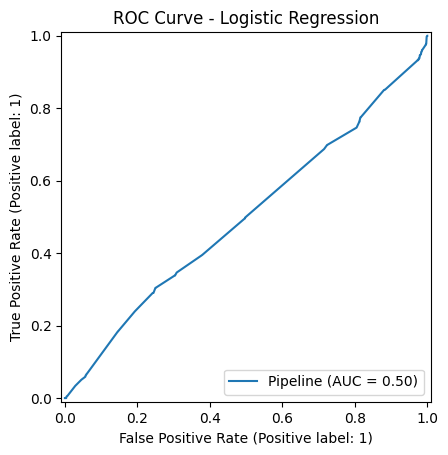

Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.74      0.84     15484
           1       0.03      0.34      0.05       355

    accuracy                           0.73     15839
   macro avg       0.50      0.54      0.45     15839
weighted avg       0.96      0.73      0.82     15839

Confusion Matrix:
[[11433  4051]
 [  234   121]]


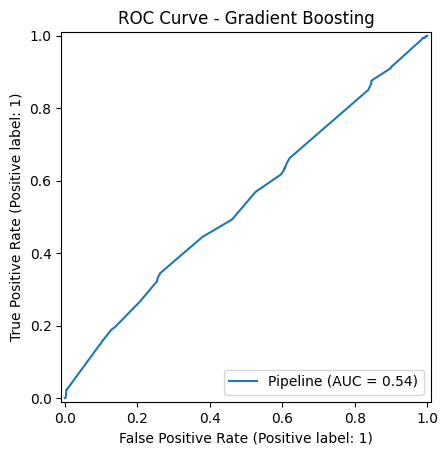

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Gradient Boosting,0.729465,0.029003,0.340845,0.053457,0.539297
0,Logistic Regression,0.616832,0.023357,0.394366,0.044101,0.498545


In [ ]:
# =========================
# 14. Clean data evaluation
# =========================

clean_results = []

for model_name, model in models.items():
    result = evaluate_model(
        model,
        X_train,
        y_train,
        X_test,
        y_test,
        model_name
    )
    clean_results.append(result)

clean_results_df = pd.DataFrame(clean_results)
display(clean_results_df.sort_values(by="F1-score", ascending=False))

## 15. Cross-Validation

Cross-validation gives a more stable estimate of model performance.

In [ ]:
# =========================
# 15. Cross-validation
# =========================

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

scoring = ["accuracy", "precision", "recall", "f1", "roc_auc"]
cv_results = []

for model_name, model in models.items():
    scores = cross_validate(
        model,
        X_train,
        y_train,
        cv=cv,
        scoring=scoring
    )

    row = {"Model": model_name}
    for metric in scoring:
        row[f"{metric}_mean"] = scores[f"test_{metric}"].mean()
        row[f"{metric}_std"] = scores[f"test_{metric}"].std()

    cv_results.append(row)

cv_results_df = pd.DataFrame(cv_results)
display(cv_results_df)

,Model,accuracy_mean,accuracy_std,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std,roc_auc_mean,roc_auc_std
0,Logistic Regression,0.530058,0.002330,0.538807,0.005719,0.421243,0.027730,0.472141,0.016586,0.535856,0.001936
1,Gradient Boosting,0.562860,0.003005,0.596630,0.003920,0.388029,0.005782,0.470224,0.005391,0.592342,0.002182


## 16. Hyperparameter Tuning for Gradient Boosting

We tune Gradient Boosting to improve performance.

In [ ]:
from sklearn.impute import SimpleImputer

# =========================
# 16. Hyperparameter tuning FIXED
# =========================

gb_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("model", GradientBoostingClassifier(random_state=RANDOM_STATE))
])

param_grid = {
    "model__n_estimators": [50, 100],
    "model__learning_rate": [0.03, 0.05, 0.10],
    "model__max_depth": [2, 3]
}

grid_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=param_grid,
    scoring="f1",
    cv=cv,
    n_jobs=-1,
    error_score="raise"
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV F1-score:", grid_search.best_score_)

best_gb_model = grid_search.best_estimator_

Best parameters: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 100}
Best CV F1-score: 0.47022351108102267


Tuned Gradient Boosting

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.74      0.84     15484
           1       0.03      0.34      0.05       355

    accuracy                           0.73     15839
   macro avg       0.50      0.54      0.45     15839
weighted avg       0.96      0.73      0.82     15839

Confusion Matrix:
[[11433  4051]
 [  234   121]]


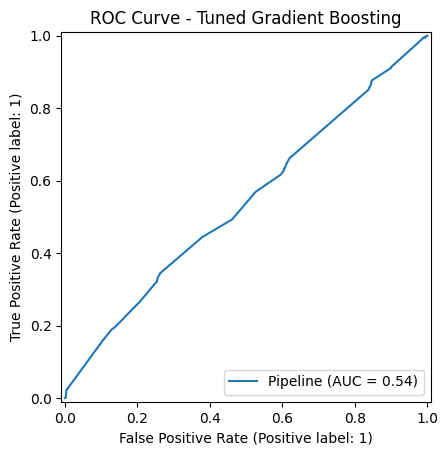

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Gradient Boosting,0.729465,0.029003,0.340845,0.053457,0.539297
2,Tuned Gradient Boosting,0.729465,0.029003,0.340845,0.053457,0.539297
0,Logistic Regression,0.616832,0.023357,0.394366,0.044101,0.498545


In [ ]:
# Evaluate tuned Gradient Boosting
tuned_gb_result = evaluate_model(
    best_gb_model,
    X_train,
    y_train,
    X_test,
    y_test,
    "Tuned Gradient Boosting"
)

clean_results_df = pd.concat(
    [clean_results_df, pd.DataFrame([tuned_gb_result])],
    ignore_index=True
)

display(clean_results_df.sort_values(by="F1-score", ascending=False))

## 17. Adversarial Condition: Label Noise

We simulate real-world labeling errors by flipping a percentage of labels in the training set.

Examples of real-world label noise:
- Incorrect diagnosis
- Data entry mistakes
- Unclear clinical status
- Delayed disease confirmation

Only training labels are modified.  
The test labels remain clean.

In [ ]:
# =========================
# 17. Add label noise
# =========================

def add_label_noise(y, noise_level=0.15, random_state=42):
    """
    Flip a percentage of binary labels.

    Parameters:
    y: target labels
    noise_level: percentage of labels to flip
    random_state: reproducibility seed

    Returns:
    y_noisy: noisy labels
    noisy_indices: indices where labels were flipped
    """

    rng = np.random.default_rng(random_state)
    y_noisy = y.copy().reset_index(drop=True)

    n_noisy = int(len(y_noisy) * noise_level)
    noisy_indices = rng.choice(len(y_noisy), size=n_noisy, replace=False)

    y_noisy.iloc[noisy_indices] = 1 - y_noisy.iloc[noisy_indices]

    return y_noisy, noisy_indices


noise_level = 0.15

X_train_noisy = X_train.reset_index(drop=True)
y_train_noisy, noisy_indices = add_label_noise(
    y_train,
    noise_level=noise_level,
    random_state=RANDOM_STATE
)

print(f"Noise level: {noise_level * 100:.0f}%")
print("Number of flipped labels:", len(noisy_indices))

print("\nOriginal training label distribution:")
display(y_train.reset_index(drop=True).value_counts().sort_index())

print("\nNoisy training label distribution:")
display(y_train_noisy.value_counts().sort_index())

Noise level: 15%
Number of flipped labels: 18579

Original training label distribution:


,count
RETURNPD_DIAG_STATUS_OL,
0,61931
1,61931



Noisy training label distribution:


,count
RETURNPD_DIAG_STATUS_OL,
0,61760
1,62102


## 18. Train and Evaluate Under Label Noise

Now we train the same models using noisy labels and evaluate them on the clean test set.

Logistic Regression - Label Noise

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.70      0.81     15484
           1       0.02      0.34      0.05       355

    accuracy                           0.69     15839
   macro avg       0.50      0.52      0.43     15839
weighted avg       0.96      0.69      0.80     15839

Confusion Matrix:
[[10780  4704]
 [  235   120]]


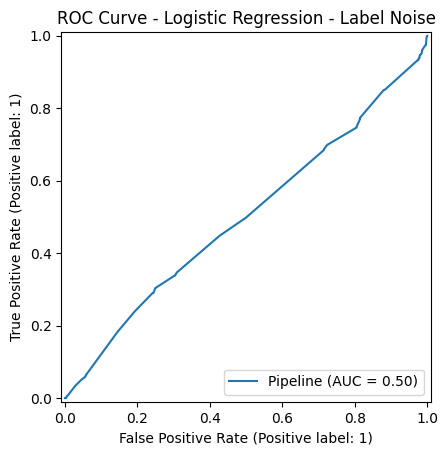

Gradient Boosting - Label Noise

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.74      0.84     15484
           1       0.03      0.34      0.05       355

    accuracy                           0.73     15839
   macro avg       0.50      0.54      0.45     15839
weighted avg       0.96      0.73      0.83     15839

Confusion Matrix:
[[11466  4018]
 [  233   122]]


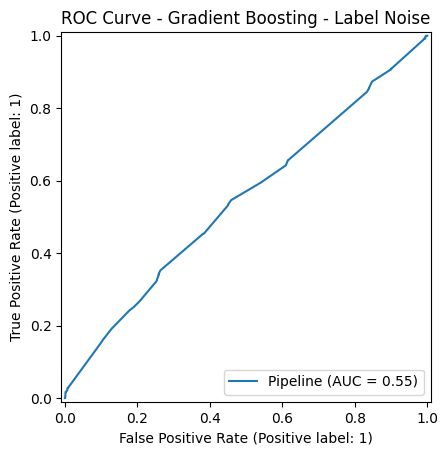

Tuned Gradient Boosting - Label Noise

Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.74      0.84     15484
           1       0.03      0.34      0.05       355

    accuracy                           0.73     15839
   macro avg       0.50      0.54      0.45     15839
weighted avg       0.96      0.73      0.83     15839

Confusion Matrix:
[[11466  4018]
 [  233   122]]


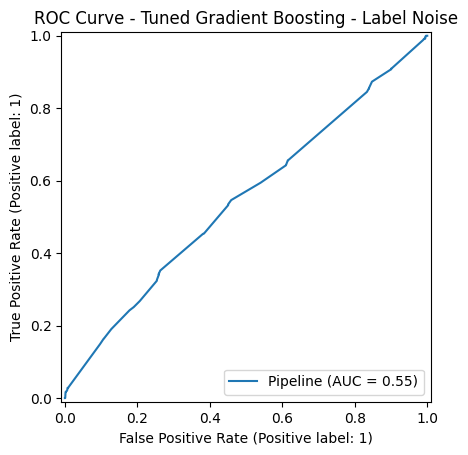

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC
1,Gradient Boosting - Label Noise,0.731612,0.029469,0.343662,0.054283,0.545483
2,Tuned Gradient Boosting - Label Noise,0.731612,0.029469,0.343662,0.054283,0.545483
0,Logistic Regression - Label Noise,0.688175,0.024876,0.338028,0.046341,0.499596


In [ ]:
# =========================
# 18. Noisy-label evaluation
# =========================

noisy_results = []

for model_name, model in models.items():
    result = evaluate_model(
        model,
        X_train_noisy,
        y_train_noisy,
        X_test,
        y_test,
        model_name + " - Label Noise"
    )
    noisy_results.append(result)

tuned_noise_result = evaluate_model(
    best_gb_model,
    X_train_noisy,
    y_train_noisy,
    X_test,
    y_test,
    "Tuned Gradient Boosting - Label Noise"
)

noisy_results.append(tuned_noise_result)

noisy_results_df = pd.DataFrame(noisy_results)
display(noisy_results_df.sort_values(by="F1-score", ascending=False))

## 19. Final Comparison

We compare model performance under:

1. Clean training data
2. Noisy-label training data

,Model,Accuracy,Precision,Recall,F1-score,ROC-AUC,Condition
1,Gradient Boosting,0.729465,0.029003,0.340845,0.053457,0.539297,Clean Training
4,Gradient Boosting - Label Noise,0.731612,0.029469,0.343662,0.054283,0.545483,Label Noise Training
0,Logistic Regression,0.616832,0.023357,0.394366,0.044101,0.498545,Clean Training
3,Logistic Regression - Label Noise,0.688175,0.024876,0.338028,0.046341,0.499596,Label Noise Training
2,Tuned Gradient Boosting,0.729465,0.029003,0.340845,0.053457,0.539297,Clean Training
5,Tuned Gradient Boosting - Label Noise,0.731612,0.029469,0.343662,0.054283,0.545483,Label Noise Training


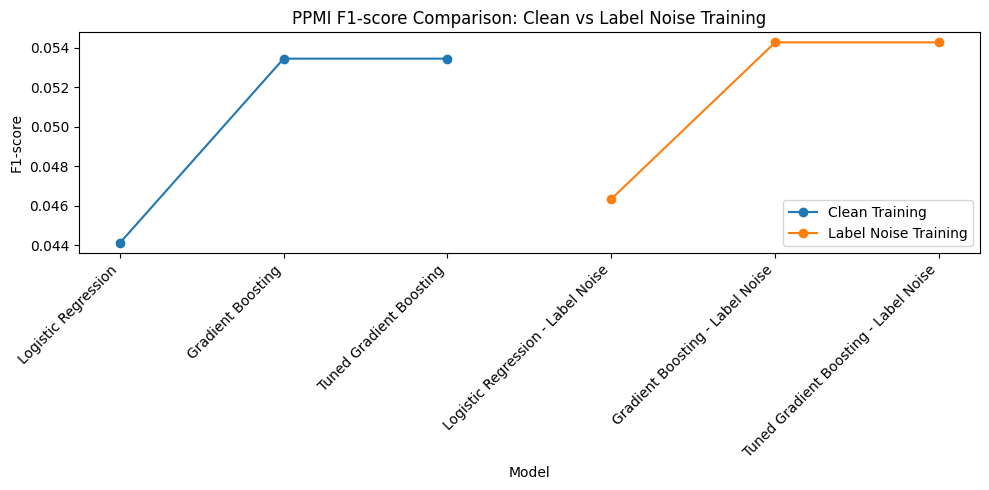

In [ ]:
# =========================
# 19. Compare results
# =========================

clean_comparison = clean_results_df.copy()
clean_comparison["Condition"] = "Clean Training"

noisy_comparison = noisy_results_df.copy()
noisy_comparison["Condition"] = "Label Noise Training"

comparison_df = pd.concat(
    [clean_comparison, noisy_comparison],
    ignore_index=True
)

display(comparison_df.sort_values(by=["Model", "Condition"]))

plt.figure(figsize=(10, 5))

for condition in comparison_df["Condition"].unique():
    subset = comparison_df[comparison_df["Condition"] == condition]
    plt.plot(
        subset["Model"],
        subset["F1-score"],
        marker="o",
        label=condition
    )

plt.title("PPMI F1-score Comparison: Clean vs Label Noise Training")
plt.xlabel("Model")
plt.ylabel("F1-score")
plt.xticks(rotation=45, ha="right")
plt.legend()
plt.tight_layout()
plt.show()

## 20. Interpretation

Use this section after running the notebook and seeing the final numbers.

### Clean Data Performance
The models were trained on clinical PPMI features.  
This is more realistic than UCI because PPMI includes clinical visit and motor assessment information.

### Logistic Regression
Logistic Regression is useful as a baseline.  
If its performance is lower, this may suggest that the relationship between clinical features and the diagnosis target is not purely linear.

### Gradient Boosting
Gradient Boosting can capture non-linear relationships and feature interactions.  
It may perform better than Logistic Regression, especially with clinical variables.

### Label Noise Impact
When label noise is added, performance may decrease because the model learns from incorrect diagnosis labels.

If the drop is large, the model is sensitive to unreliable clinical labels.

## 21. Honest Limitation Analysis

1. **Target mapping assumption**  
   The binary target was created by treating the majority diagnosis class as `0` and all other classes as `1`.  
   This must be clinically verified before final reporting.

2. **Missing values**  
   Clinical datasets often contain missing values. Median imputation is simple but may not fully capture clinical complexity.

3. **Limited feature selection**  
   This notebook uses a simplified set of features. More PPMI clinical variables may improve performance.

4. **Patient-level leakage risk**  
   The same patient may appear in multiple visits. A stronger approach would split by patient ID, not only by row.

5. **Clinical complexity**  
   Parkinson's disease diagnosis cannot be fully captured by a few motor and visit features.

6. **Not clinically deployable alone**  
   The model is suitable for educational analysis and screening research, not real clinical deployment.

7. **Need for domain validation**  
   The meaning of `RETURNPD_DIAG_STATUS_OL` should be confirmed from PPMI documentation before final conclusions.

## 22. Final Conclusion

This notebook built a complete machine learning pipeline using PPMI clinical data.

The workflow included:
- Loading multiple PPMI files
- Merging by `PATNO` and `EVENT_ID`
- Cleaning missing values
- Creating a binary target
- Training Logistic Regression and Gradient Boosting
- Evaluating clean data performance
- Testing robustness under label noise

Compared with the UCI dataset, PPMI is more realistic but also more challenging due to missing values, multiple files, clinical encoding, and possible repeated patient visits.